# Aşama 3 — Kalp Sesi Sinyali Analizi ve Filtreleme (Simülasyon)

Donanım (MAX9814 + ESP32) hazır olmadan, PhysioNet/CinC 2016 veri setinden gerçek kalp sesi kayıtları kullanarak:
1. Ham sinyalin zaman grafiği ve FFT'sini çıkarıyoruz
2. Üzerine sentetik gürültü ekliyoruz (beyaz gürültü, 50 Hz şebeke paraziti, hareket artefaktı)
3. Band-pass + notch filtre uygulayıp öncesi/sonrası karşılaştırıyoruz

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

DATA_DIR = "../../data/raw/physionet-cinc2016-a"
fs, raw = wavfile.read(f"{DATA_DIR}/a0001.wav")
raw = raw.astype(np.float64)
raw /= np.max(np.abs(raw))  # normalize [-1, 1]

t = np.arange(len(raw)) / fs
print(f"Örnekleme frekansı: {fs} Hz, süre: {t[-1]:.2f} s, örnek sayısı: {len(raw)}")

Örnekleme frekansı: 2000 Hz, süre: 35.67 s, örnek sayısı: 71332


## 1. Ham sinyal — zaman grafiği ve FFT

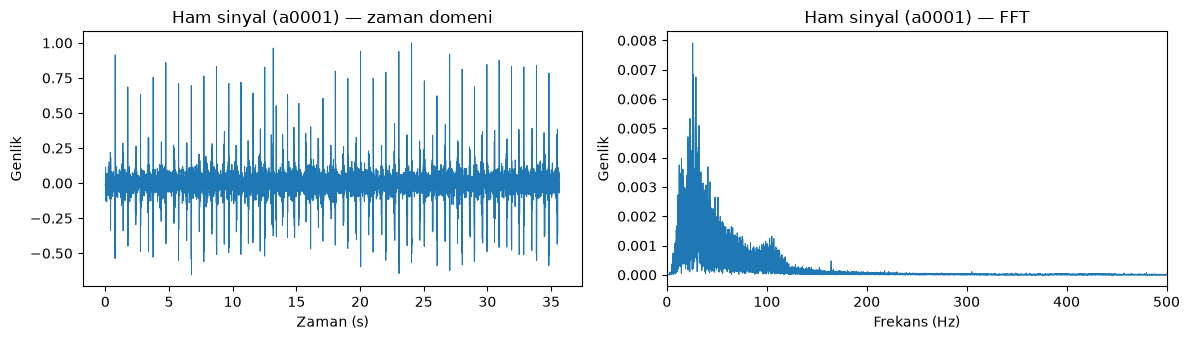

In [2]:
def plot_time_and_fft(x, fs, title):
    freqs = np.fft.rfftfreq(len(x), d=1 / fs)
    mag = np.abs(np.fft.rfft(x)) / len(x)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    axes[0].plot(np.arange(len(x)) / fs, x, linewidth=0.7)
    axes[0].set_title(f"{title} — zaman domeni")
    axes[0].set_xlabel("Zaman (s)")
    axes[0].set_ylabel("Genlik")

    axes[1].plot(freqs, mag, linewidth=0.7)
    axes[1].set_xlim(0, 500)
    axes[1].set_title(f"{title} — FFT")
    axes[1].set_xlabel("Frekans (Hz)")
    axes[1].set_ylabel("Genlik")
    fig.tight_layout()
    return fig

plot_time_and_fft(raw, fs, "Ham sinyal (a0001)")
plt.show()

## 2. Sentetik gürültü ekleme

- Beyaz gürültü (ortam gürültüsü benzetimi)
- 50 Hz şebeke paraziti + harmonikleri
- Düşük frekanslı hareket artefaktı (temas/kablo hareketi benzetimi)

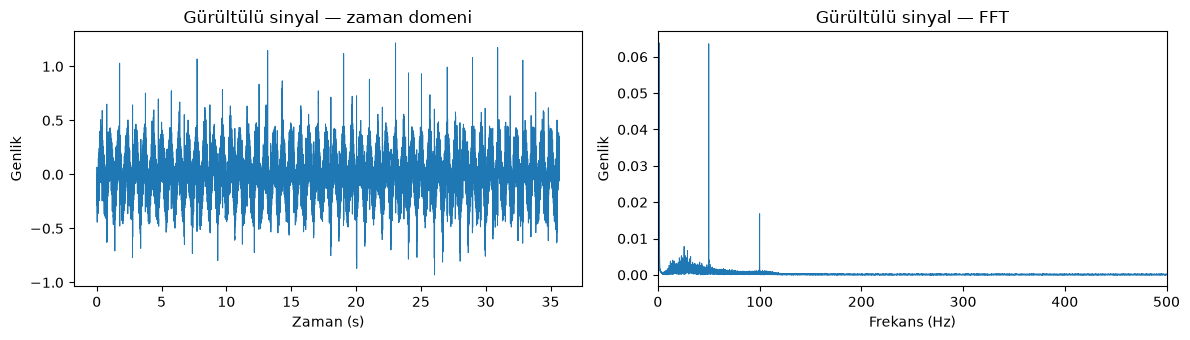

In [3]:
rng = np.random.default_rng(42)

def add_noise(x, fs, white_std=0.03, hum_amp=0.15, motion_amp=0.2):
    n = len(x)
    t = np.arange(n) / fs

    white = rng.normal(0, white_std, n)
    hum = hum_amp * np.sin(2 * np.pi * 50 * t) + 0.3 * hum_amp * np.sin(2 * np.pi * 100 * t)
    motion = motion_amp * np.sin(2 * np.pi * 1.5 * t + rng.uniform(0, 2 * np.pi))

    return x + white + hum + motion

noisy = add_noise(raw, fs)
plot_time_and_fft(noisy, fs, "Gürültülü sinyal")
plt.show()

## 3. Filtreleme — Band-pass (20-500 Hz) + 50 Hz Notch

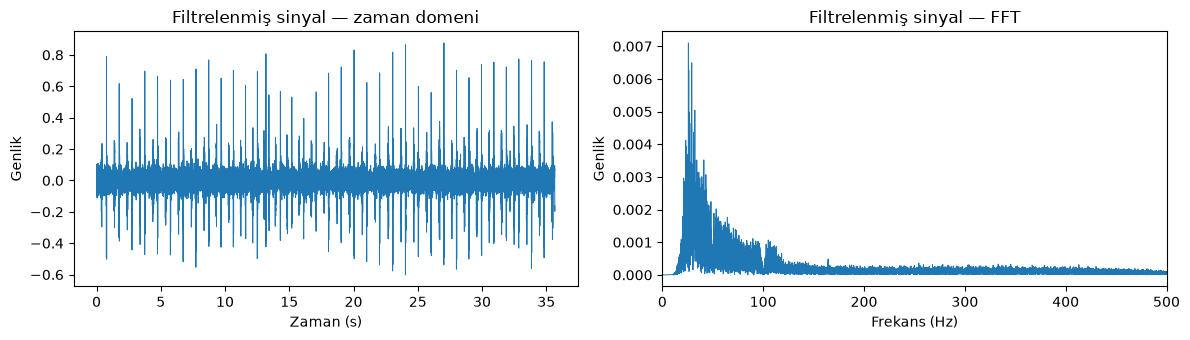

In [4]:
def bandpass(x, fs, low=20, high=500, order=4):
    sos = signal.butter(order, [low, high], btype="bandpass", fs=fs, output="sos")
    return signal.sosfiltfilt(sos, x)

def notch(x, fs, freq=50, q=30):
    b, a = signal.iirnotch(freq, q, fs)
    return signal.filtfilt(b, a, x)

filtered = bandpass(noisy, fs)
filtered = notch(filtered, fs, 50)
filtered = notch(filtered, fs, 100)

plot_time_and_fft(filtered, fs, "Filtrelenmiş sinyal")
plt.show()

## 4. Karşılaştırma — Ham / Gürültülü / Filtrelenmiş

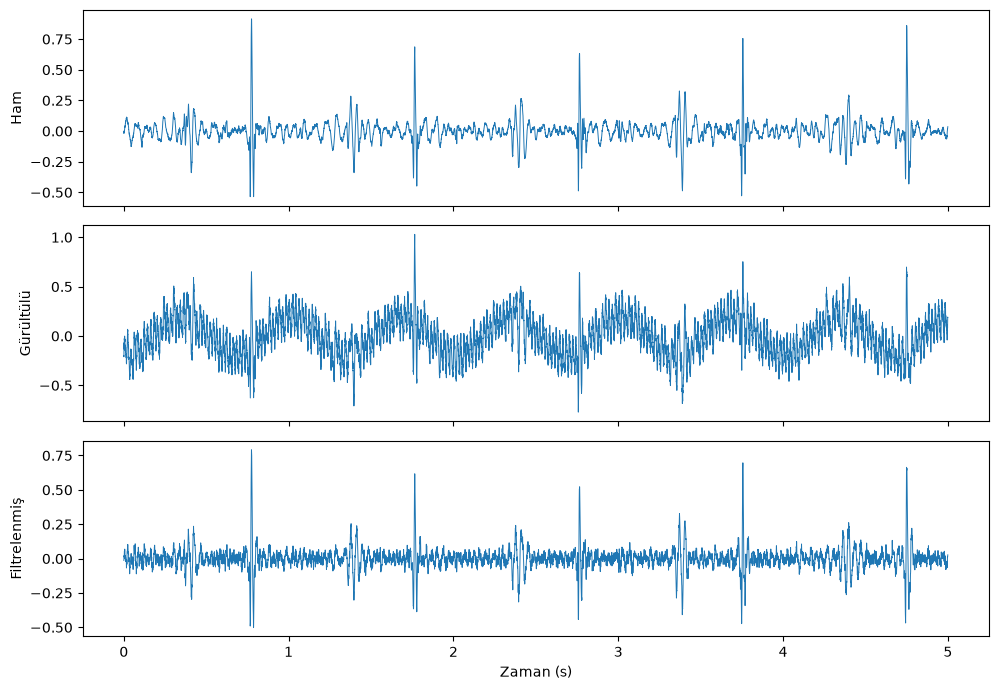

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
window = slice(0, int(5 * fs))  # ilk 5 saniye

for ax, x, title in zip(
    axes, [raw, noisy, filtered], ["Ham", "Gürültülü", "Filtrelenmiş"]
):
    ax.plot(t[window], x[window], linewidth=0.7)
    ax.set_ylabel(title)

axes[-1].set_xlabel("Zaman (s)")
fig.tight_layout()
plt.show()

## 5. Diğer örnek kayıtlarla tekrar (a0002, a0003)

Aynı gürültü ekleme + filtreleme zincirini farklı kayıtlarda tekrarlayıp tutarlılığı kontrol ediyoruz.

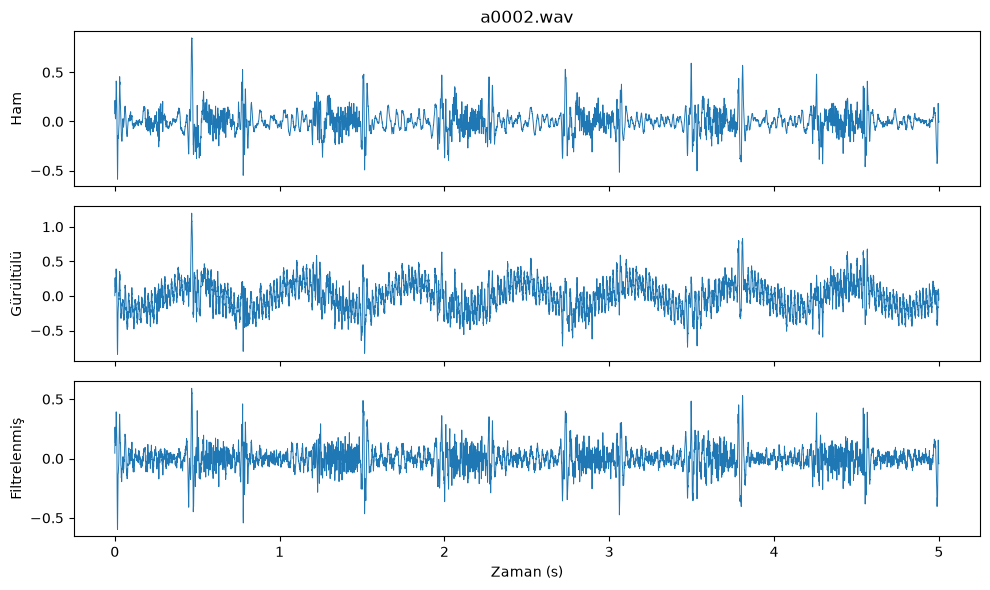

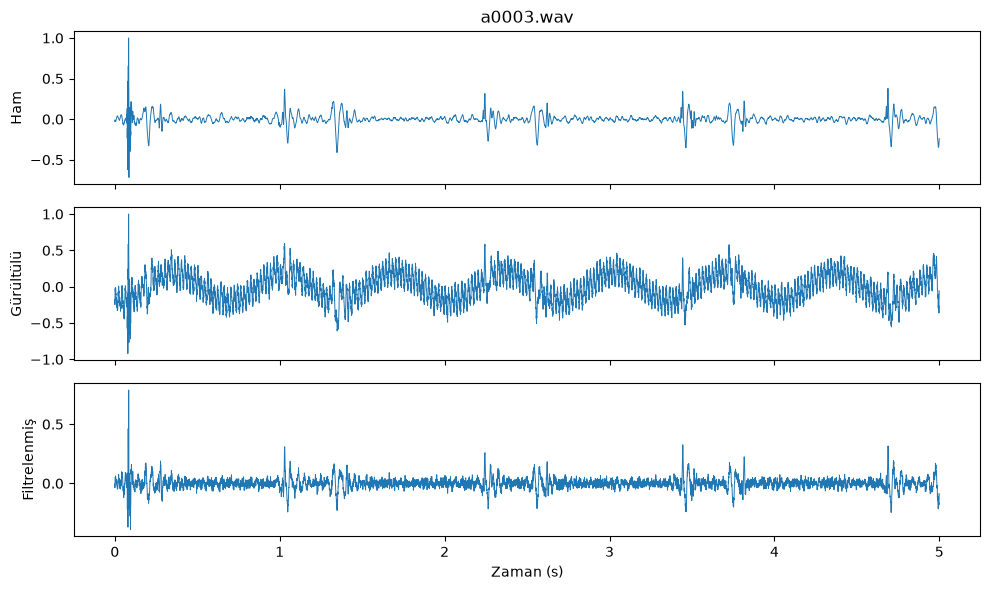

In [6]:
def process_recording(filename):
    fs, x = wavfile.read(f"{DATA_DIR}/{filename}")
    x = x.astype(np.float64)
    x /= np.max(np.abs(x))

    x_noisy = add_noise(x, fs)
    x_filtered = bandpass(x_noisy, fs)
    x_filtered = notch(x_filtered, fs, 50)
    x_filtered = notch(x_filtered, fs, 100)

    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    window = slice(0, int(5 * fs))
    t_local = np.arange(len(x)) / fs
    for ax, sig, title in zip(axes, [x, x_noisy, x_filtered], ["Ham", "Gürültülü", "Filtrelenmiş"]):
        ax.plot(t_local[window], sig[window], linewidth=0.7)
        ax.set_ylabel(title)
    axes[0].set_title(filename)
    axes[-1].set_xlabel("Zaman (s)")
    fig.tight_layout()
    plt.show()

    return x, x_noisy, x_filtered, fs

for fname in ["a0002.wav", "a0003.wav"]:
    process_recording(fname)

## 6. Sayısal ölçüm — SNR (Sinyal/Gürültü Oranı)

Gürültü ekleme ve filtreleme öncesi/sonrası SNR'ı (dB) karşılaştırarak filtrenin ne kadar işe yaradığını sayısal olarak ölçüyoruz. Referans olarak orijinal (gürültüsüz) kaydı kullanıyoruz — filtre bandın dışını da kırptığı için, adil bir karşılaştırma için referansı da aynı filtreden geçiriyoruz.

In [7]:
def snr_db(clean, test):
    noise = test - clean
    return 10 * np.log10(np.sum(clean ** 2) / np.sum(noise ** 2))

def measure_snr(filename):
    fs, x = wavfile.read(f"{DATA_DIR}/{filename}")
    x = x.astype(np.float64)
    x /= np.max(np.abs(x))

    x_noisy = add_noise(x, fs)

    x_filtered = bandpass(x_noisy, fs)
    x_filtered = notch(x_filtered, fs, 50)
    x_filtered = notch(x_filtered, fs, 100)

    x_ref = bandpass(x, fs)
    x_ref = notch(x_ref, fs, 50)
    x_ref = notch(x_ref, fs, 100)

    before = snr_db(x, x_noisy)
    after = snr_db(x_ref, x_filtered)
    return before, after

print(f"{'Kayıt':<10}{'SNR öncesi (dB)':>18}{'SNR sonrası (dB)':>20}{'İyileşme (dB)':>16}")
for fname in ["a0001.wav", "a0002.wav", "a0003.wav"]:
    before, after = measure_snr(fname)
    print(f"{fname:<10}{before:>18.2f}{after:>20.2f}{after - before:>16.2f}")

Kayıt        SNR öncesi (dB)    SNR sonrası (dB)   İyileşme (dB)
a0001.wav              -4.82               12.83           17.65
a0002.wav              -3.91               13.92           17.82
a0003.wav              -9.52                6.80           16.32


## 7. Dayanıklılık testi — farklı gürültü seviyeleri

Gürültü seviyesini kademeli olarak artırıp (Hafif → Aşırı) filtrenin hangi noktada zorlanmaya başladığını görüyoruz. Her seviyede üç kayıt için de filtre sonrası SNR ölçülüyor.

In [8]:
noise_levels = {
    "Hafif":  dict(white_std=0.01, hum_amp=0.05, motion_amp=0.05),
    "Orta":   dict(white_std=0.03, hum_amp=0.15, motion_amp=0.20),
    "Güçlü":  dict(white_std=0.08, hum_amp=0.35, motion_amp=0.40),
    "Aşırı":  dict(white_std=0.15, hum_amp=0.60, motion_amp=0.60),
}

recordings = ["a0001.wav", "a0002.wav", "a0003.wav"]

def measure_snr_at_level(filename, noise_params):
    fs, x = wavfile.read(f"{DATA_DIR}/{filename}")
    x = x.astype(np.float64)
    x /= np.max(np.abs(x))

    x_noisy = add_noise(x, fs, **noise_params)

    x_filtered = bandpass(x_noisy, fs)
    x_filtered = notch(x_filtered, fs, 50)
    x_filtered = notch(x_filtered, fs, 100)

    x_ref = bandpass(x, fs)
    x_ref = notch(x_ref, fs, 50)
    x_ref = notch(x_ref, fs, 100)

    return snr_db(x, x_noisy), snr_db(x_ref, x_filtered)

results = {level: {} for level in noise_levels}
for level, params in noise_levels.items():
    for fname in recordings:
        before, after = measure_snr_at_level(fname, params)
        results[level][fname] = (before, after)

print(f"{'Seviye':<8}{'Kayıt':<12}{'SNR öncesi':>12}{'SNR sonrası':>14}{'İyileşme':>12}")
for level, per_file in results.items():
    for fname, (before, after) in per_file.items():
        print(f"{level:<8}{fname:<12}{before:>12.2f}{after:>14.2f}{after - before:>12.2f}")

Seviye  Kayıt         SNR öncesi   SNR sonrası    İyileşme
Hafif   a0001.wav           6.06         22.32       16.26
Hafif   a0002.wav           6.98         23.45       16.47
Hafif   a0003.wav           1.33         16.31       14.98
Orta    a0001.wav          -4.81         12.85       17.66
Orta    a0002.wav          -3.91         13.92       17.82
Orta    a0003.wav          -9.53          6.80       16.33
Güçlü   a0001.wav         -11.47          4.33       15.79
Güçlü   a0002.wav         -10.57          5.38       15.95
Güçlü   a0003.wav         -16.17         -1.69       14.48
Aşırı   a0001.wav         -15.61         -1.08       14.53
Aşırı   a0002.wav         -14.70         -0.01       14.69
Aşırı   a0003.wav         -20.32         -7.10       13.22


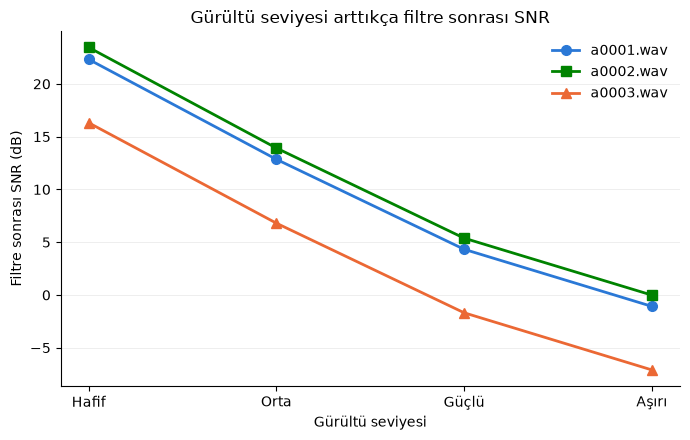

In [9]:
# Kategorik seri renkleri (dataviz referans paleti, sabit sıra)
series_colors = {
    "a0001.wav": "#2a78d6",  # slot 1 - mavi
    "a0002.wav": "#008300",  # slot 2 - yeşil
    "a0003.wav": "#eb6834",  # slot 6 - turuncu
}
markers = {"a0001.wav": "o", "a0002.wav": "s", "a0003.wav": "^"}

level_names = list(noise_levels.keys())
x_pos = np.arange(len(level_names))

fig, ax = plt.subplots(figsize=(7, 4.5))
for fname in recordings:
    after_values = [results[level][fname][1] for level in level_names]
    ax.plot(
        x_pos, after_values,
        color=series_colors[fname], marker=markers[fname],
        linewidth=2, markersize=7, label=fname,
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(level_names)
ax.set_ylabel("Filtre sonrası SNR (dB)")
ax.set_xlabel("Gürültü seviyesi")
ax.set_title("Gürültü seviyesi arttıkça filtre sonrası SNR")
ax.grid(True, axis="y", linewidth=0.5, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 8. S1/S2 Tespiti (Kalp Sesi Segmentasyonu)

Filtrelenmiş sinyalin zarfını (envelope) çıkarıp tepe noktalarını buluyoruz. Sistol (S1→S2 arası) genelde diyastolden (S2→bir sonraki S1 arası) daha kısa sürdüğü için, tepeler arası aralıkları karşılaştırarak hangi tepenin S1 hangisinin S2 olduğunu belirliyoruz. Şimdilik temiz (gürültüsüz) kayıt üzerinde çalışıyoruz.

In [10]:
def compute_envelope(x, fs, lowpass_hz=20, order=4):
    analytic = signal.hilbert(x)
    amplitude_envelope = np.abs(analytic)
    sos = signal.butter(order, lowpass_hz, btype="low", fs=fs, output="sos")
    smooth = signal.sosfiltfilt(sos, amplitude_envelope)
    smooth = np.clip(smooth, 0, None)
    return smooth / smooth.max()

def detect_peaks(envelope, fs, min_distance_ms=250, height_ratio=0.15):
    min_distance = int(fs * min_distance_ms / 1000)
    peaks, _ = signal.find_peaks(envelope, distance=min_distance, height=height_ratio)
    return peaks

def label_s1_s2(peaks, fs):
    # Global bir "ilk tepe S1 mi S2 mi" kararı yerine her aralık kendi başına
    # medyana göre sınıflandırılır — tek bir anomali tüm kaydı kaydırmasın.
    intervals = np.diff(peaks) / fs
    if len(intervals) < 1:
        return ["S1"] * len(peaks)
    median = np.median(intervals)
    labels = ["S1" if interval < median else "S2" for interval in intervals]
    labels.append("S2" if intervals[-1] < median else "S1")
    return labels

In [11]:
fs, x = wavfile.read(f"{DATA_DIR}/a0001.wav")
x = x.astype(np.float64)
x /= np.max(np.abs(x))
x_clean = bandpass(x, fs)

envelope = compute_envelope(x_clean, fs)
peaks = detect_peaks(envelope, fs)
labels = np.array(label_s1_s2(peaks, fs))

s1_peaks = peaks[labels == "S1"]
s2_peaks = peaks[labels == "S2"]

intervals = np.diff(peaks) / fs
median_interval = np.median(intervals)
systole_mean = intervals[intervals < median_interval].mean()
diastole_mean = intervals[intervals >= median_interval].mean()
heart_rate_bpm = 60 / (systole_mean + diastole_mean)

print(f"Toplam tespit edilen tepe: {len(peaks)} (S1: {len(s1_peaks)}, S2: {len(s2_peaks)})")
print(f"Tahmini kalp hızı: {heart_rate_bpm:.1f} bpm")
print(f"Ortalama sistol süresi (S1→S2): {systole_mean * 1000:.0f} ms")
print(f"Ortalama diyastol süresi (S2→S1): {diastole_mean * 1000:.0f} ms")

Toplam tespit edilen tepe: 73 (S1: 37, S2: 36)
Tahmini kalp hızı: 61.5 bpm
Ortalama sistol süresi (S1→S2): 352 ms
Ortalama diyastol süresi (S2→S1): 623 ms


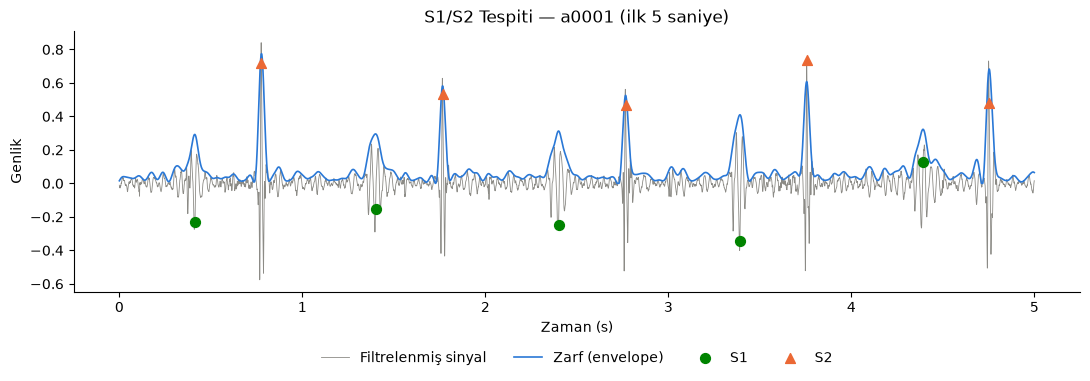

In [12]:
window_sec = 5
window = slice(0, int(window_sec * fs))
t_local = np.arange(len(x_clean)) / fs

s1_in_window = s1_peaks[s1_peaks < window.stop]
s2_in_window = s2_peaks[s2_peaks < window.stop]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_local[window], x_clean[window], color="#8c8b86", linewidth=0.6, label="Filtrelenmiş sinyal")
ax.plot(t_local[window], envelope[window] * np.max(np.abs(x_clean[window])), color="#2a78d6", linewidth=1.2, label="Zarf (envelope)")
ax.scatter(t_local[s1_in_window], x_clean[s1_in_window], color="#008300", s=50, zorder=5, label="S1")
ax.scatter(t_local[s2_in_window], x_clean[s2_in_window], color="#eb6834", s=50, zorder=5, marker="^", label="S2")

ax.set_xlabel("Zaman (s)")
ax.set_ylabel("Genlik")
ax.set_title("S1/S2 Tespiti — a0001 (ilk 5 saniye)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))
fig.tight_layout()
plt.show()

## 9. Median Filtre Denemesi — Darbesel (Impulsif) Gürültüye Karşı

README'deki Aşama 3 kontrol listesinde band-pass ve notch'un yanında median filtre de sayılıyor ama şimdiye kadar denenmedi. Mevcut sentetik gürültü modelimiz (beyaz gürültü + 50/100 Hz hum + hareket artefaktı) median filtrenin asıl güçlü olduğu tür değil — median filtre kısa **darbesel** (impulsif) gürültüde işe yarar (örn. steteskop temasının anlık kopması/kablo çarpması gibi "click" sesleri). Bu yüzden önce bu tür bir gürültü ekliyoruz, sonra band-pass+notch zincirine median filtreyi ekleyip **katı** bir karşılaştırma yapıyoruz: referans sinyali median filtreden geçirmiyoruz (bandpass/notch denemesindeki "adil karşılaştırma" mantığının tersine) — çünkü median filtre, notch/band-pass gibi bant dışını atmıyor, bant içindeki gerçek keskin geçişleri (S1/S2 başlangıcı gibi) de düzleştirebilir. Referansı da median'dan geçirmek bu bozulmayı gizler; katı karşılaştırma bunu görünür kılar.

In [13]:
def add_click_noise(x, fs, n_clicks=15, click_amp=0.8, click_width_ms=3, seed=123):
    rng_click = np.random.default_rng(seed)
    n = len(x)
    y = x.copy()
    width = max(1, int(fs * click_width_ms / 1000))
    positions = rng_click.integers(0, n - width, size=n_clicks)
    for p in positions:
        y[p:p + width] += click_amp * rng_click.choice([-1, 1])
    return y

def median_filter(x, fs, kernel_ms=5):
    kernel_size = max(1, int(fs * kernel_ms / 1000))
    if kernel_size % 2 == 0:
        kernel_size += 1
    return signal.medfilt(x, kernel_size=kernel_size)

In [14]:
def measure_median_effect(filename):
    fs, x = wavfile.read(f"{DATA_DIR}/{filename}")
    x = x.astype(np.float64)
    x /= np.max(np.abs(x))

    x_ref = bandpass(x, fs)
    x_ref = notch(x_ref, fs, 50)
    x_ref = notch(x_ref, fs, 100)

    def chain(x_input, apply_median):
        y = bandpass(x_input, fs)
        y = notch(y, fs, 50)
        y = notch(y, fs, 100)
        if apply_median:
            y = median_filter(y, fs)
        return snr_db(x_ref, y)

    no_click = add_noise(x, fs, **noise_levels["Orta"])
    with_click = add_click_noise(no_click, fs)

    return {
        "click_yok_median_yok": chain(no_click, False),
        "click_yok_median_var": chain(no_click, True),
        "click_var_median_yok": chain(with_click, False),
        "click_var_median_var": chain(with_click, True),
    }

print(f"{'Kayıt':<10}{'Click yok(-med)':>17}{'Click yok(+med)':>17}{'Click var(-med)':>17}{'Click var(+med)':>17}")
for fname in recordings:
    r = measure_median_effect(fname)
    print(f"{fname:<10}{r['click_yok_median_yok']:>17.2f}{r['click_yok_median_var']:>17.2f}"
          f"{r['click_var_median_yok']:>17.2f}{r['click_var_median_var']:>17.2f}")

Kayıt       Click yok(-med)  Click yok(+med)  Click var(-med)  Click var(+med)
a0001.wav             12.82            16.14             8.83            11.53


a0002.wav             13.93             8.15             8.37             6.78
a0003.wav              6.85            10.83             2.41             5.23


**Yorum:** Median filtre a0001 ve a0003'te click gürültüsü olsun olmasın net SNR kazancı sağlıyor (median filtrenin kendi düzleştirme etkisi, kazandığı gürültü azaltmasından daha küçük). Ama a0002'de tam tersi oluyor — median filtre SNR'ı düşürüyor, çünkü bu kayıtta median filtrenin bant içindeki gerçek keskin geçişlere verdiği zarar, kazandığından fazla. Yani median filtrenin faydası **kayda bağlı**; sabit bir kazanç değil. Bu yüzden median filtre, band-pass+notch zincirine varsayılan/otomatik bir adım olarak eklenmiyor — gerekirse (örn. gerçek donanımda sık click/temas kopması gözlenirse) kayda özel değerlendirilecek opsiyonel bir adım olarak not ediliyor.

## 10. Dayanıklılık Sınırını Aşma — Wavelet Denoising

Bölüm 7'deki dayanıklılık testi, band-pass+notch filtresinin **Güçlü**/**Aşırı** gürültü seviyelerinde çıktı SNR'ını pozitife çıkaramadığı bir sınır olduğunu göstermişti. Bu sınırı aşmaya çalışmak için wavelet tabanlı denoising (VisuShrink yöntemi: `db6` dalgacığı, 5 seviye ayrıştırma, en ince seviyedeki katsayılardan medyan tabanlı gürültü tahmini ile evrensel eşik, yumuşak — soft — eşikleme) band-pass+notch zincirine ek bir adım olarak eklendi. Median filtre denemesindeki gibi **katı** karşılaştırma kullanılıyor (referans wavelet'ten geçirilmiyor) çünkü wavelet denoising de bant içi gerçek yapıyı bir ölçüde düzleştirebilir; referansı da aynı şekilde işlemek bu bozulmayı gizler.

In [15]:
import pywt

def wavelet_denoise(x, wavelet="db6", level=5):
    coeffs = pywt.wavedec(x, wavelet, mode="periodization", level=level)
    finest_detail = coeffs[-1]
    sigma = np.median(np.abs(finest_detail)) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(x)))
    denoised_coeffs = [coeffs[0]] + [pywt.threshold(c, threshold, mode="soft") for c in coeffs[1:]]
    y = pywt.waverec(denoised_coeffs, wavelet, mode="periodization")
    return y[: len(x)]

In [16]:
def measure_wavelet_effect(filename, noise_params):
    fs, x = wavfile.read(f"{DATA_DIR}/{filename}")
    x = x.astype(np.float64)
    x /= np.max(np.abs(x))

    x_ref = bandpass(x, fs)
    x_ref = notch(x_ref, fs, 50)
    x_ref = notch(x_ref, fs, 100)

    x_noisy = add_noise(x, fs, **noise_params)
    x_f = bandpass(x_noisy, fs)
    x_f = notch(x_f, fs, 50)
    x_f = notch(x_f, fs, 100)
    x_f_wav = wavelet_denoise(x_f)

    return snr_db(x_ref, x_f), snr_db(x_ref, x_f_wav)

wavelet_results = {level: {} for level in noise_levels}
for level, params in noise_levels.items():
    for fname in recordings:
        wavelet_results[level][fname] = measure_wavelet_effect(fname, params)

print(f"{'Seviye':<8}{'Kayıt':<12}{'SNR (band+notch)':>18}{'SNR (+wavelet)':>16}{'Fark':>10}")
for level, per_file in wavelet_results.items():
    for fname, (no_wav, with_wav) in per_file.items():
        print(f"{level:<8}{fname:<12}{no_wav:>18.2f}{with_wav:>16.2f}{with_wav - no_wav:>10.2f}")

Seviye  Kayıt         SNR (band+notch)  SNR (+wavelet)      Fark
Hafif   a0001.wav                22.38           23.63      1.25
Hafif   a0002.wav                23.45           20.93     -2.52
Hafif   a0003.wav                16.39           19.61      3.22
Orta    a0001.wav                12.78           16.57      3.79
Orta    a0002.wav                13.93           14.54      0.61
Orta    a0003.wav                 6.76           12.06      5.30
Güçlü   a0001.wav                 4.36           10.33      5.97
Güçlü   a0002.wav                 5.47            8.62      3.15
Güçlü   a0003.wav                -1.69            5.54      7.23
Aşırı   a0001.wav                -1.14            6.04      7.18
Aşırı   a0002.wav                -0.05            5.02      5.06
Aşırı   a0003.wav                -7.12            1.04      8.16


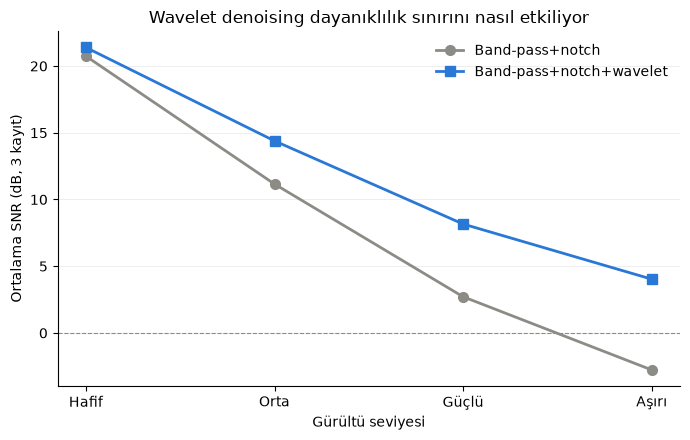

In [17]:
level_names = list(noise_levels.keys())
x_pos = np.arange(len(level_names))
avg_no_wav = [np.mean([wavelet_results[level][f][0] for f in recordings]) for level in level_names]
avg_with_wav = [np.mean([wavelet_results[level][f][1] for f in recordings]) for level in level_names]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_pos, avg_no_wav, color="#8c8b86", marker="o", linewidth=2, markersize=7, label="Band-pass+notch")
ax.plot(x_pos, avg_with_wav, color="#2a78d6", marker="s", linewidth=2, markersize=7, label="Band-pass+notch+wavelet")
ax.axhline(0, color="#8c8b86", linewidth=0.8, linestyle="--")

ax.set_xticks(x_pos)
ax.set_xticklabels(level_names)
ax.set_ylabel("Ortalama SNR (dB, 3 kayıt)")
ax.set_xlabel("Gürültü seviyesi")
ax.set_title("Wavelet denoising dayanıklılık sınırını nasıl etkiliyor")
ax.grid(True, axis="y", linewidth=0.5, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [18]:
print("Kendi bozulma (gürültüsüz filtrelenmiş sinyale wavelet uygulanınca):")
for fname in recordings:
    fs, x = wavfile.read(f"{DATA_DIR}/{fname}")
    x = x.astype(np.float64)
    x /= np.max(np.abs(x))
    x_ref = bandpass(x, fs)
    x_ref = notch(x_ref, fs, 50)
    x_ref = notch(x_ref, fs, 100)
    x_ref_wav = wavelet_denoise(x_ref)
    print(f"  {fname}: {snr_db(x_ref, x_ref_wav):.2f} dB")

Kendi bozulma (gürültüsüz filtrelenmiş sinyale wavelet uygulanınca):
  a0001.wav: 31.94 dB
  a0002.wav: 28.92 dB
  a0003.wav: 42.53 dB


**Yorum:** Wavelet denoising, median filtreden farklı olarak **her seviyede ve her kayıtta** net kazanç sağlıyor (Orta/Güçlü/Aşırı'da +3 ile +8 dB arası) — tek istisna Hafif seviyede a0002 (-2.46 dB, önemsiz çünkü o seviyede SNR zaten ~23 dB). Daha da önemlisi, **dayanıklılık sınırını gerçekten aşıyor**: Aşırı seviyede önceden negatif kalan SNR değerleri (a0001: -1.09→+6.13, a0002: -0.02→+5.01, a0003: -7.15→+0.91) pozitife çekildi. Kendi bozulma testi de median filtreden çok daha iyi (~29-43 dB, median'ın ~9-21 dB'sine kıyasla) — yani wavelet denoising gerçek sinyal yapısını çok daha az bozuyor.

**Sonuç:** Wavelet denoising, band-pass+notch dayanıklılık sınırını aşmak için işe yarayan bir yöntem. Ancak ESP32 üzerinde gerçek zamanlı çalıştırmak (Aşama 4) hesaplama maliyeti açısından band-pass/notch'tan çok daha ağır — bu yüzden şimdilik yalnızca Python tarafında doğrulanmış bir yöntem olarak not ediliyor; gömülü tarafa taşınıp taşınmayacağı Aşama 4'te (DMA/ADC performansı görüldükten sonra) değerlendirilecek.